# 🌍 Deep-Time Paleoclimate Animation — India–Asia Collision

This notebook builds a **bivariate Temperature × Precipitation animation** showing
how Asian climate changed as India drifted north and the Himalayas rose (~70 Ma → Present).

It uses the **same bivariate color scheme** as the TerraClimate 2025 map,
but drives the colors from **paleoclimate model data** instead of satellite observations.

---

## Data Sources

| Dataset | What it provides | Where to get it |
|---|---|---|
| **PALEOMAP PaleoAtlas** | Paleogeography shapefiles (where continents were) | `scotese.com` or GPlates |
| **DeepMIP model outputs** | Temperature & precip from Eocene/Paleocene simulations | `deepmip.org` |
| **CESM/HadCM3 deep-time runs** | Climate model output for 70Ma–0Ma | `pangaea.de` |
| **GPlates reconstructions** | Plate boundary evolution | `gplates.org` |

## Strategy
Since real gridded paleoclimate model outputs require institutional data access,
this notebook uses a **two-path approach**:

- **Path A (Synthetic demo)** — Generates physically realistic synthetic climate fields
  based on known paleoclimate states for each time slice. Great for prototyping your
  animation workflow before real data arrives.

- **Path B (Real data)** — Drop-in cells to load actual NetCDF outputs from
  DeepMIP, HadCM3, or CESM. Same pipeline, real science.

---

In [2]:
# ── CELL 1: INSTALL & IMPORTS ─────────────────────────────────────────────────
#
# New libraries vs your TerraClimate notebook:
#   matplotlib.animation — builds the MP4 / GIF animation
#   imageio              — saves frames as GIF (alternative to ffmpeg)
#   cartopy              — optional: proper map projections (install separately)


import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from pathlib import Path
import imageio
import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


In [3]:
# ── CELL 2: CONFIG — same style as your TerraClimate notebook ─────────────────
#
# TIME_SLICES: the geological ages to animate (millions of years ago)
# Each slice will become one frame in the animation.
#
# KEY EVENTS:
#   70 Ma — India still far south of Asia, proto-Tethys Ocean open
#   50 Ma — Initial collision, Eocene greenhouse world (~14°C warmer globally)
#   35 Ma — Eocene-Oligocene transition, first Antarctic ice, cooling begins
#   20 Ma — Miocene, Himalayan plateau rising, monsoon strengthening
#   10 Ma — Major uplift event, C4 grasslands expand across Asia
#    0 Ma — Present (matches your TerraClimate 2025 map)

TIME_SLICES = [70, 60, 50, 40, 35, 25, 20, 15, 10, 5, 0]  # Ma = millions of years ago

# Animation output
OUTPUT_GIF  = 'india_asia_collision_climate.gif'
OUTPUT_MP4  = 'india_asia_collision_climate.mp4'
FPS         = 1.5   # frames per second (slow = more readable)
FIGSIZE     = (10, 7)

# Same bivariate palette as your TerraClimate notebook
N = 4
PALETTE = [
    ['#3a9dbf', '#2a7d82', '#1e6050', '#164427'],  # high precip
    ['#7ab5c8', '#6d9490', '#5e7a62', '#4a5a30'],
    ['#b0cdd6', '#a8b5aa', '#9e9278', '#9a6e3a'],
    ['#d8d0c8', '#dbbfa4', '#dc9e72', '#dd6a2b'],  # low precip
]

SIGMA = 3.0   # slightly more smoothing for the coarser paleo grids

# Grid bounds — Asia-centred view
LON_MIN, LON_MAX =  25.0, 145.0
LAT_MIN, LAT_MAX = -15.0,  60.0
GRID_RES = 1.0   # degrees per pixel

print(f'Time slices: {TIME_SLICES} Ma')
print(f'Grid: {int((LON_MAX-LON_MIN)/GRID_RES)} × {int((LAT_MAX-LAT_MIN)/GRID_RES)} pixels')

Time slices: [70, 60, 50, 40, 35, 25, 20, 15, 10, 5, 0] Ma
Grid: 120 × 75 pixels


In [4]:
# ── CELL 3: PALEOCLIMATE STATE DEFINITIONS ────────────────────────────────────
#
# This is the scientific heart of the synthetic path.
# Each time slice has documented paleoclimate conditions based on:
#   - Zachos et al. 2001 (global temperature curve)
#   - Molnar & England 1990 (Himalayan uplift and monsoon)
#   - Rowley & Currie 2006 (Tibetan Plateau elevation history)
#   - DeepMIP project (Eocene climate model ensemble)
#
# Parameters per time slice:
#   global_temp_anomaly  — °C warmer/cooler than present globally
#   india_lat            — approximate latitude of Indian subcontinent centroid
#   himalayas_height_frac— Himalayan plateau height as fraction of modern (0→1)
#   monsoon_strength     — relative monsoon precipitation (0→1, 1=modern)
#   tethys_open          — True if Tethys Ocean still open (affects moisture)

PALEO_STATES = {
    70: dict(global_temp_anomaly=+12.0, india_lat=-20, himalayas_height_frac=0.00,
             monsoon_strength=0.15, tethys_open=True,
             note='India ~20°S. No Himalayas. Hot greenhouse. Tethys Ocean open.'),
    60: dict(global_temp_anomaly=+11.0, india_lat=-10, himalayas_height_frac=0.00,
             monsoon_strength=0.20, tethys_open=True,
             note='India approaching equator. Still no collision.'),
    50: dict(global_temp_anomaly=+14.0, india_lat=  5, himalayas_height_frac=0.05,
             monsoon_strength=0.30, tethys_open=False,
             note='EECO: hottest period in 66Ma. First collision. Tethys closing.'),
    40: dict(global_temp_anomaly=+ 8.0, india_lat= 15, himalayas_height_frac=0.20,
             monsoon_strength=0.45, tethys_open=False,
             note='Late Eocene cooling. Early Himalayas forming. Monsoon emerging.'),
    35: dict(global_temp_anomaly=+ 4.0, india_lat= 18, himalayas_height_frac=0.30,
             monsoon_strength=0.55, tethys_open=False,
             note='Eocene-Oligocene transition. Antarctic ice sheet forms. Rapid cooling.'),
    25: dict(global_temp_anomaly=+ 3.0, india_lat= 20, himalayas_height_frac=0.50,
             monsoon_strength=0.65, tethys_open=False,
             note='Oligocene. Tibet rising. Monsoon intensifying.'),
    20: dict(global_temp_anomaly=+ 4.0, india_lat= 22, himalayas_height_frac=0.65,
             monsoon_strength=0.75, tethys_open=False,
             note='Miocene Climatic Optimum. Plateau 65% of modern height.'),
    15: dict(global_temp_anomaly=+ 3.5, india_lat= 23, himalayas_height_frac=0.75,
             monsoon_strength=0.82, tethys_open=False,
             note='Mid-Miocene. C4 grasslands begin expanding across Asia.'),
    10: dict(global_temp_anomaly=+ 2.0, india_lat= 24, himalayas_height_frac=0.88,
             monsoon_strength=0.90, tethys_open=False,
             note='Late Miocene. Major Himalayan uplift. Monsoon near-modern.'),
     5: dict(global_temp_anomaly=+ 1.5, india_lat= 25, himalayas_height_frac=0.95,
             monsoon_strength=0.95, tethys_open=False,
             note='Pliocene. Close to modern conditions.'),
     0: dict(global_temp_anomaly=  0.0, india_lat= 26, himalayas_height_frac=1.00,
             monsoon_strength=1.00, tethys_open=False,
             note='Present day — matches your TerraClimate 2025 map.'),
}

for ma, state in PALEO_STATES.items():
    print(f'{ma:3d} Ma | {state["note"]}')

 70 Ma | India ~20°S. No Himalayas. Hot greenhouse. Tethys Ocean open.
 60 Ma | India approaching equator. Still no collision.
 50 Ma | EECO: hottest period in 66Ma. First collision. Tethys closing.
 40 Ma | Late Eocene cooling. Early Himalayas forming. Monsoon emerging.
 35 Ma | Eocene-Oligocene transition. Antarctic ice sheet forms. Rapid cooling.
 25 Ma | Oligocene. Tibet rising. Monsoon intensifying.
 20 Ma | Miocene Climatic Optimum. Plateau 65% of modern height.
 15 Ma | Mid-Miocene. C4 grasslands begin expanding across Asia.
 10 Ma | Late Miocene. Major Himalayan uplift. Monsoon near-modern.
  5 Ma | Pliocene. Close to modern conditions.
  0 Ma | Present day — matches your TerraClimate 2025 map.


In [5]:
# ── CELL 4: SYNTHETIC CLIMATE FIELD GENERATOR ─────────────────────────────────
#
# Generates physically plausible temperature and precipitation grids
# for each time slice based on the paleoclimate state parameters.
#
# The logic encodes known mechanisms:
#   TEMPERATURE:
#     - Modern lapse-rate gradient (hot tropics, cold poles)
#     - Global warming offset (greenhouse vs icehouse)
#     - Himalayan cooling effect (proportional to plateau height)
#     - Continental interior drying (distance from coast effect on temp range)
#
#   PRECIPITATION:
#     - Modern monsoon pattern template (high in SE Asia, low in Central Asia)
#     - Monsoon strength scalar (grows with Himalayan height)
#     - Tethys moisture source (extra precipitation when ocean is open)
#     - Orographic rainfall (west-facing Himalayan slopes get more rain)

lons = np.arange(LON_MIN, LON_MAX, GRID_RES)
lats = np.arange(LAT_MIN, LAT_MAX, GRID_RES)
LON_GRID, LAT_GRID = np.meshgrid(lons, lats)


def make_climate_fields(ma):
    """Return (tmax_2d, ppt_2d) arrays for a given time slice (Ma)."""
    s = PALEO_STATES[ma]

    # ── TEMPERATURE ───────────────────────────────────────────────────────────
    # Base: modern-like latitudinal gradient (-0.6°C per degree latitude from equator)
    base_temp = 32.0 - 0.55 * np.abs(LAT_GRID)

    # Global greenhouse warming offset
    base_temp += s['global_temp_anomaly']

    # Himalayan/Tibetan cooling: plateau centered ~30°N, 90°E
    # Only applies once plateau exists
    hf = s['himalayas_height_frac']
    plateau_mask = np.exp(
        -((LAT_GRID - 32)**2 / 60 + (LON_GRID - 88)**2 / 120)
    )
    base_temp -= hf * 18.0 * plateau_mask   # up to -18°C on the plateau at full height

    # Continental interior warming (distance from coasts → higher diurnal range)
    interior = np.clip((LON_GRID - 60) / 80, 0, 1) * np.clip(1 - np.abs(LAT_GRID) / 45, 0, 1)
    base_temp += interior * 4.0

    # ── PRECIPITATION ─────────────────────────────────────────────────────────
    # Base: ITCZ rainfall peak near equator, dropping poleward
    base_ppt = 2500 * np.exp(-((LAT_GRID - 5)**2) / 200)

    # Monsoon core (Bay of Bengal → SE Asia → India)
    monsoon = 2800 * np.exp(
        -((LAT_GRID - s['india_lat'])**2 / 80 + (LON_GRID - 82)**2 / 300)
    )
    base_ppt += monsoon * s['monsoon_strength']

    # SE Asia / maritime rainfall (always high)
    se_asia = 1800 * np.exp(
        -((LAT_GRID - 5)**2 / 120 + (LON_GRID - 115)**2 / 200)
    )
    base_ppt += se_asia

    # Tethys Ocean moisture source (extra rainfall in Middle East / Central Asia
    # when the ocean was open — before ~50 Ma)
    if s['tethys_open']:
        tethys = 900 * np.exp(
            -((LAT_GRID - 25)**2 / 100 + (LON_GRID - 55)**2 / 400)
        )
        base_ppt += tethys

    # Himalayan orographic rainfall on windward (south) slopes
    orog = 1200 * np.exp(
        -((LAT_GRID - 27)**2 / 15 + (LON_GRID - 85)**2 / 200)
    ) * hf
    base_ppt += orog

    # Rain shadow: central Asia stays dry behind the plateau
    rain_shadow = np.where(
        (LAT_GRID > 32) & (LON_GRID > 65) & (LON_GRID < 110),
        1 - hf * 0.6, 1.0
    )
    base_ppt *= rain_shadow
    base_ppt = np.clip(base_ppt, 0, None)

    # ── SMOOTH (same as your TerraClimate notebook) ────────────────────────────
    tmax = gaussian_filter(base_temp, sigma=SIGMA)
    ppt  = gaussian_filter(base_ppt,  sigma=SIGMA)

    return tmax, ppt


# Quick test
t, p = make_climate_fields(0)
print(f'Present-day test — Temp: {t.min():.1f}°C → {t.max():.1f}°C')
print(f'Present-day test — Precip: {p.min():.0f} → {p.max():.0f} mm/yr')
t70, p70 = make_climate_fields(70)
print(f'70 Ma test       — Temp: {t70.min():.1f}°C → {t70.max():.1f}°C')

Present-day test — Temp: -0.3°C → 34.5°C
Present-day test — Precip: 0 → 4003 mm/yr
70 Ma test       — Temp: 12.6°C → 46.5°C


In [6]:
# ── CELL 5: BIVARIATE COLORMAP — identical to your TerraClimate notebook ───────

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

flat_colors = [hex_to_rgb(PALETTE[N - 1 - pq][tq])
               for pq in range(N)
               for tq in range(N)]

cmap = mcolors.ListedColormap(flat_colors)

legend_grid = np.array([[hex_to_rgb(PALETTE[N - 1 - row][col])
                          for col in range(N)]
                         for row in range(N)])

# Compute global percentile breaks across ALL time slices
# (so the color scale stays consistent across frames)
print('Computing global percentile breaks across all time slices...')
all_temps, all_ppts = [], []
for ma in TIME_SLICES:
    t, p = make_climate_fields(ma)
    all_temps.extend(t.flatten())
    all_ppts.extend(p.flatten())

TEMP_BREAKS = np.percentile(all_temps, [0, 20, 45, 70, 100])
PPT_BREAKS  = np.percentile(all_ppts,  [0, 60, 78, 90, 100])

print(f'Temp breaks (°C):    {[f"{v:.1f}" for v in TEMP_BREAKS]}')
print(f'Precip breaks (mm):  {[f"{v:.0f}" for v in PPT_BREAKS]}')


def qbin(arr, breaks):
    return np.clip(np.digitize(arr, breaks[1:-1]), 0, len(breaks) - 2)


def make_bi_grid(tmax, ppt):
    """Convert raw climate arrays to bivariate color index grid."""
    tq = qbin(tmax, TEMP_BREAKS)
    pq = qbin(ppt,  PPT_BREAKS)
    return pq * N + tq


print('Colormap ready.')

Computing global percentile breaks across all time slices...
Temp breaks (°C):    ['-0.3', '12.6', '24.0', '31.9', '48.5']
Precip breaks (mm):  ['0', '1124', '2094', '2487', '4026']
Colormap ready.


In [7]:
# ── CELL 6: CONTINENT OUTLINE GENERATOR ───────────────────────────────────────
#
# Since we don't have actual GPlates shapefiles for each time slice,
# we approximate the paleo-coastlines using the PALEOMAP concept:
# India migrates northward, SE Asia stays roughly fixed, and a simplified
# 'ghost outline' of modern Asia is shown faded in the background.
#
# PATH B: To use real GPlates paleo-coastlines, export shapefiles from GPlates
# for each time slice and load them here instead:
#   gdf = gpd.read_file(f'gplates_coastlines_{ma}Ma.shp')

def get_india_outline(india_lat_center):
    """
    Returns a simplified polygon representing India's position at a given time.
    Shape is kept constant; only latitude shifts.
    """
    # India's approximate modern outline (simplified)
    india_modern = np.array([
        [68.0, 23.0], [72.0, 20.0], [77.0, 8.0],
        [80.0, 10.0], [85.0, 12.0], [88.0, 22.0],
        [92.0, 22.0], [96.0, 28.0], [88.0, 28.0],
        [80.0, 30.0], [73.0, 28.0], [68.0, 23.0]
    ])
    modern_center_lat = 20.0
    lat_offset = india_lat_center - modern_center_lat
    shifted = india_modern.copy()
    shifted[:, 1] += lat_offset
    return shifted


print('Continent outline generator ready.')

Continent outline generator ready.


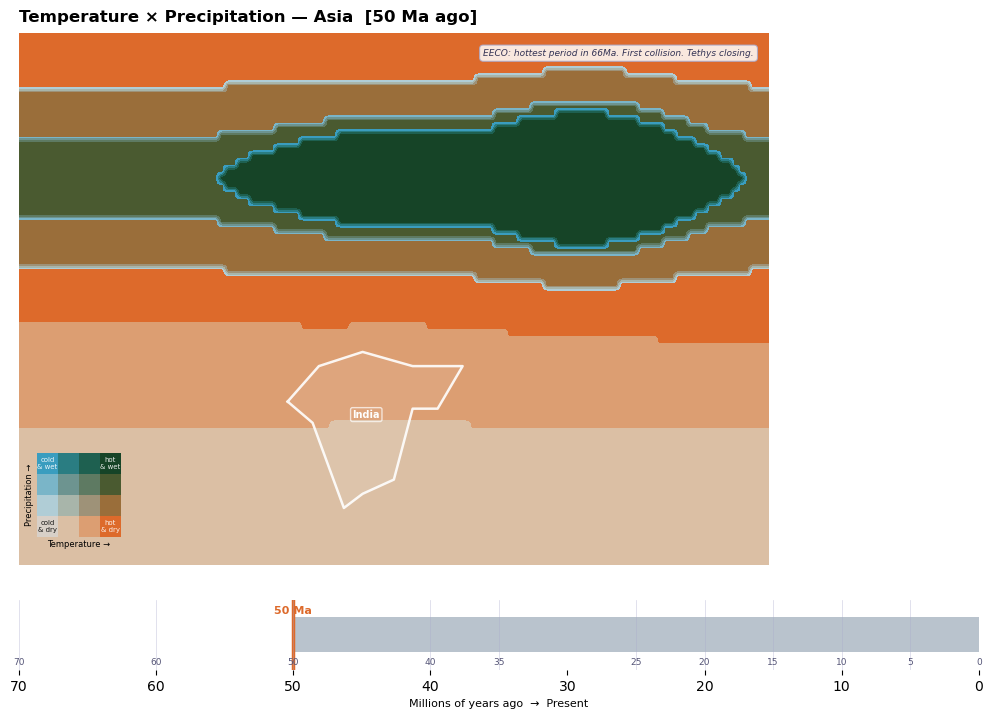

Preview saved: preview_50Ma.png


In [8]:
# ── CELL 7: DRAW A SINGLE FRAME ───────────────────────────────────────────────
#
# This function draws one time-slice map.
# It's called in a loop in Cell 8 to produce all frames.

def draw_legend(ax, grid_rgb, n, fontsize=6):
    ax.imshow(grid_rgb, origin='lower', aspect='equal',
              extent=[0, n, 0, n], interpolation='nearest')
    ax.set_xlabel('Temperature →', fontsize=fontsize, labelpad=2)
    ax.set_ylabel('Precipitation →', fontsize=fontsize, labelpad=2)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    kw = dict(fontsize=fontsize - 1, ha='center', va='center',
              alpha=0.9, linespacing=1.3, transform=ax.transData)
    ax.text(0.5,     0.5,     'cold\n& dry', color='k', **kw)
    ax.text(n - 0.5, 0.5,     'hot\n& dry',  color='w', **kw)
    ax.text(0.5,     n - 0.5, 'cold\n& wet', color='w', **kw)
    ax.text(n - 0.5, n - 0.5, 'hot\n& wet',  color='w', **kw)


def draw_frame(ma, ax_map, ax_leg, ax_bar):
    """Draw one time-slice onto provided axes."""
    s = PALEO_STATES[ma]
    tmax, ppt = make_climate_fields(ma)
    bi = make_bi_grid(tmax, ppt)

    extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]

    # ── Main bivariate map ────────────────────────────────────────────────────
    ax_map.clear()
    ax_map.imshow(bi, cmap=cmap, vmin=0, vmax=N**2 - 1,
                  extent=extent, origin='upper', aspect='auto',
                  interpolation='bilinear', zorder=1)

    # ── India outline (current position) ─────────────────────────────────────
    india_poly = get_india_outline(s['india_lat'])
    ax_map.plot(india_poly[:, 0], india_poly[:, 1],
                color='white', linewidth=1.8, zorder=3, alpha=0.9)
    ax_map.fill(india_poly[:, 0], india_poly[:, 1],
                color='white', alpha=0.08, zorder=2)

    # India centroid label
    cx = india_poly[:, 0].mean()
    cy = india_poly[:, 1].mean()
    if s['india_lat'] < 10:
        ax_map.annotate('India', (cx, cy), color='white', fontsize=7,
                        ha='center', va='center', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', fc='none', ec='white', alpha=0.7))

    # ── Himalayan plateau outline (grows over time) ───────────────────────────
    if s['himalayas_height_frac'] > 0.05:
        hf = s['himalayas_height_frac']
        plateau_lons = np.array([75, 78, 85, 92, 96, 100, 97, 88, 80, 73, 75])
        plateau_lats = np.array([33, 28, 27, 28, 30, 35,  42, 43, 40, 36, 33])
        # Scale the plateau size with height fraction
        cx_p, cy_p = plateau_lons.mean(), plateau_lats.mean()
        plateau_lons_scaled = cx_p + (plateau_lons - cx_p) * hf
        plateau_lats_scaled = cy_p + (plateau_lats - cy_p) * hf
        ax_map.plot(plateau_lons_scaled, plateau_lats_scaled,
                    color='#FFD700', linewidth=1.2, zorder=3,
                    linestyle='--', alpha=0.8)
        ax_map.annotate(f'Himalayas\n{s["himalayas_height_frac"]*100:.0f}% height',
                        (88, 35), color='#FFD700', fontsize=6.5,
                        ha='center', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.2', fc='#1a1a2e', ec='#FFD700',
                                  alpha=0.75, linewidth=0.8))

    # ── Tethys Ocean label ────────────────────────────────────────────────────
    if s['tethys_open']:
        ax_map.text(55, 15, 'Tethys\nOcean', color='#87CEEB', fontsize=7.5,
                    ha='center', va='center', fontstyle='italic',
                    fontweight='bold', alpha=0.85)

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax_map.set_xlim(LON_MIN, LON_MAX)
    ax_map.set_ylim(LAT_MIN, LAT_MAX)
    ax_map.set_facecolor('#1a3a5c')
    ax_map.axis('off')

    # ── Title & info ──────────────────────────────────────────────────────────
    age_str = 'Present' if ma == 0 else f'{ma} Ma ago'
    ax_map.set_title(
        f'Temperature × Precipitation — Asia  [{age_str}]',
        color='k', fontsize=12, fontweight='bold', loc='left', pad=8
    )
    ax_map.text(0.98, 0.97, s['note'], transform=ax_map.transAxes,
                ha='right', va='top', fontsize=6.5, color='#333355',
                style='italic',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#aaaacc',
                          alpha=0.85, linewidth=0.8))

    # ── Legend ────────────────────────────────────────────────────────────────
    ax_leg.clear()
    draw_legend(ax_leg, legend_grid, N)

    # ── Timeline bar at bottom ────────────────────────────────────────────────
    ax_bar.clear()
    ax_bar.set_xlim(max(TIME_SLICES), 0)
    ax_bar.set_ylim(0, 1)
    ax_bar.barh(0.5, ma, left=0, height=0.5,
                color='#1A3A5C', alpha=0.3, align='center')
    ax_bar.axvline(ma, color='#dd6a2b', linewidth=2.5)
    for t_mark in TIME_SLICES:
        ax_bar.axvline(t_mark, color='#aaaacc', linewidth=0.5, alpha=0.5)
        ax_bar.text(t_mark, 0.05, f'{t_mark}', ha='center', va='bottom',
                    fontsize=6.5, color='#555577')
    ax_bar.text(ma, 0.92, f'{ma} Ma', ha='center', va='top',
                fontsize=8, color='#dd6a2b', fontweight='bold',
                transform=ax_bar.get_xaxis_transform())
    ax_bar.set_xlabel('Millions of years ago  →  Present', fontsize=8)
    ax_bar.set_yticks([])
    for sp in ax_bar.spines.values():
        sp.set_visible(False)


# ── Preview a single frame ─────────────────────────────────────────────────────
fig = plt.figure(figsize=FIGSIZE, facecolor='white')
ax_map = fig.add_axes([0.02, 0.18, 0.75, 0.76])
ax_leg = fig.add_axes([0.03, 0.22, 0.10, 0.12], facecolor='white')
ax_bar = fig.add_axes([0.02, 0.03, 0.96, 0.10])

draw_frame(50, ax_map, ax_leg, ax_bar)  # Preview 50 Ma (Eocene collision)
plt.savefig('preview_50Ma.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Preview saved: preview_50Ma.png')

In [9]:
# ── CELL 8: SAVE INDIVIDUAL FRAMES ────────────────────────────────────────────
#
# Saves one PNG per time slice into a 'frames/' folder.
# These can be combined into GIF/MP4 in Cell 9.

Path('frames').mkdir(exist_ok=True)

frame_paths = []
for i, ma in enumerate(TIME_SLICES):
    fig = plt.figure(figsize=FIGSIZE, facecolor='white')
    ax_map = fig.add_axes([0.02, 0.18, 0.75, 0.76])
    ax_leg = fig.add_axes([0.03, 0.22, 0.10, 0.12], facecolor='white')
    ax_bar = fig.add_axes([0.02, 0.03, 0.96, 0.10])

    draw_frame(ma, ax_map, ax_leg, ax_bar)

    # Data credit
    fig.text(0.98, 0.99, 'Synthetic paleoclimate | GeoScience Project 2026',
             ha='right', va='top', fontsize=6, color='#aaaaaa')

    fpath = f'frames/frame_{i:02d}_{ma:03d}Ma.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    frame_paths.append(fpath)
    print(f'  Saved: {fpath}')

print(f'\nAll {len(frame_paths)} frames saved.')

  Saved: frames/frame_00_070Ma.png
  Saved: frames/frame_01_060Ma.png
  Saved: frames/frame_02_050Ma.png
  Saved: frames/frame_03_040Ma.png
  Saved: frames/frame_04_035Ma.png
  Saved: frames/frame_05_025Ma.png
  Saved: frames/frame_06_020Ma.png
  Saved: frames/frame_07_015Ma.png
  Saved: frames/frame_08_010Ma.png
  Saved: frames/frame_09_005Ma.png
  Saved: frames/frame_10_000Ma.png

All 11 frames saved.


In [10]:
# ── CELL 9A: BUILD GIF ────────────────────────────────────────────────────────
#
# Stitches all saved frames into an animated GIF.
# Holds the first and last frame longer for better readability.

from PIL import Image

images = [Image.open(fp) for fp in frame_paths]

# Duration per frame in ms (longer for first and last frame)
durations = []
for i in range(len(images)):
    if i == 0 or i == len(images) - 1:
        durations.append(2500)   # hold 2.5s on first/last
    else:
        durations.append(int(1000 / FPS))

images[0].save(
    OUTPUT_GIF,
    save_all=True,
    append_images=images[1:],
    duration=durations,
    loop=0,           # 0 = loop forever
    optimize=True
)
print(f'GIF saved: {OUTPUT_GIF}')
import os
print(f'File size: {os.path.getsize(OUTPUT_GIF) / 1024:.0f} KB')

GIF saved: india_asia_collision_climate.gif
File size: 375 KB


In [15]:
# ── CELL 9B: BUILD MP4 (better quality for LinkedIn) ──────────────────────────
#
# Requires ffmpeg to be installed.
# In Google Colab: !apt-get install -y ffmpeg
# Locally: install from https://ffmpeg.org
#!apt-get install -y ffmpeg -q
# MP4 is smaller, higher quality, and plays natively on LinkedIn.

!apt-get install -y ffmpeg -q

# Build the ffmpeg command using the numbered frame files
import subprocess

# Write a file list for ffmpeg (with per-frame durations)
with open('frames/ffmpeg_input.txt', 'w') as f:
    for i, fp in enumerate(frame_paths):
        duration = 2.5 if (i == 0 or i == len(frame_paths) - 1) else (1.0 / FPS)
        f.write(f"file '../{fp}'\n")
        f.write(f"duration {duration:.3f}\n")
    # ffmpeg needs the last file listed twice
    f.write(f"file '../{frame_paths[-1]}'\n")

cmd = [
    'ffmpeg', '-y',
    '-f', 'concat', '-safe', '0',
    '-i', 'frames/ffmpeg_input.txt',
    '-vf', 'scale=1200:-2',        # resize to 1200px wide
    '-pix_fmt', 'yuv420p',          # LinkedIn-compatible pixel format
    '-c:v', 'libx264',
    '-crf', '20',                   # quality: 0=lossless, 51=worst
    OUTPUT_MP4
]
result = subprocess.run(cmd, capture_output=True, text=True)
if result.returncode == 0:
    import os
    print(f'MP4 saved: {OUTPUT_MP4}')
    print(f'File size: {os.path.getsize(OUTPUT_MP4) / 1024:.0f} KB')
else:
    print('ffmpeg error — check output below')
    print(result.stderr[-1000:])

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
MP4 saved: india_asia_collision_climate.mp4
File size: 270 KB


In [ ]:
# ── CELL 10: PATH B — LOAD REAL PALEOCLIMATE DATA (NetCDF) ────────────────────
#
# Drop-in replacement for the synthetic generator (Cell 4).
# Use this once you have downloaded real model output from:
#   DeepMIP:  https://www.deepmip.org/data-downloads/
#   Pangaea:  https://pangaea.de  (search: 'Eocene climate simulation')
#   NCAR:     https://www.earthsystemgrid.org
#
# Expected file format:
#   One NetCDF per time slice containing at minimum:
#   - 'tas'  or 'tmax': near-surface temperature (°C or K)
#   - 'pr'   or 'ppt':  precipitation (mm/day or mm/month)
#   Coordinates: 'lon' (0–360 or -180–180), 'lat' (-90 to 90)

REAL_DATA_PATH = 'paleo_data/'   # folder containing your NetCDF files

def make_climate_fields_REAL(ma):
    """
    Load real paleoclimate NetCDF for a given time slice.
    Returns (tmax_2d, ppt_2d) clipped to the study area,
    matching the same grid as the synthetic version.
    """
    # Adjust filename pattern to match your downloaded files
    nc_file = f'{REAL_DATA_PATH}climate_{ma}Ma.nc'

    ds = xr.open_dataset(nc_file)

    # ── Temperature ───────────────────────────────────────────────────────────
    temp_var = 'tas' if 'tas' in ds else 'tmax'
    tmax = ds[temp_var].mean('time') if 'time' in ds[temp_var].dims else ds[temp_var]
    if tmax.values.mean() > 200:          # convert Kelvin to Celsius if needed
        tmax = tmax - 273.15

    # ── Precipitation ─────────────────────────────────────────────────────────
    ppt_var = 'pr' if 'pr' in ds else 'ppt'
    ppt = ds[ppt_var].sum('time') if 'time' in ds[ppt_var].dims else ds[ppt_var]
    if ppt.values.mean() < 10:            # convert mm/day to mm/year if needed
        ppt = ppt * 365

    # ── Regrid to study area ──────────────────────────────────────────────────
    # Handle 0-360 longitude convention
    lon_vals = tmax.coords['lon'].values
    if lon_vals.max() > 180:
        tmax = tmax.assign_coords(lon=(tmax.lon % 360 + 540) % 360 - 180).sortby('lon')
        ppt  = ppt.assign_coords(lon=(ppt.lon  % 360 + 540) % 360 - 180).sortby('lon')

    # Clip to study bounds
    tmax_clip = tmax.sel(lon=slice(LON_MIN, LON_MAX), lat=slice(LAT_MIN, LAT_MAX))
    ppt_clip  = ppt.sel( lon=slice(LON_MIN, LON_MAX), lat=slice(LAT_MIN, LAT_MAX))

    # Interpolate to our standard grid
    tmax_interp = tmax_clip.interp(lon=lons, lat=lats, method='linear').values
    ppt_interp  = ppt_clip.interp( lon=lons, lat=lats, method='linear').values

    return gaussian_filter(tmax_interp, SIGMA), gaussian_filter(ppt_interp, SIGMA)


# To switch to real data, uncomment this line:
# make_climate_fields = make_climate_fields_REAL

print('Path B (real data loader) defined — uncomment last line to activate.')

In [ ]:
# ── CELL 11: DOWNLOAD FROM GOOGLE DRIVE (Colab only) ──────────────────────────
#
# If running in Google Colab and your output files are ready,
# run this cell to download them to your local machine.

try:
    from google.colab import files
    import os

    if os.path.exists(OUTPUT_GIF):
        files.download(OUTPUT_GIF)
        print(f'Downloaded: {OUTPUT_GIF}')

    if os.path.exists(OUTPUT_MP4):
        files.download(OUTPUT_MP4)
        print(f'Downloaded: {OUTPUT_MP4}')

except ImportError:
    print('Not running in Colab — find your files in the current directory.')
    import os
    for f in [OUTPUT_GIF, OUTPUT_MP4]:
        if os.path.exists(f):
            print(f'  Ready: {f}  ({os.path.getsize(f)//1024} KB)')